# Synthetic modelling of the mitochondrial permeability transition pore (mPTP) in cardiac ischemia-reperfusion and cancer stress adaptation

## Proof-of-concept notebook 
## Purpose

This notebook provides a **proof-of-concept computational workflow** for the proposed Wellcome-style programme on the **molecular identity and state-dependent gating of the mitochondrial permeability transition pore, mPTP**.

The notebook uses **simulated and synthetic data** rather than patient or experimental data. The synthetic values are **benchmarked to broad qualitative and semi-quantitative trends** reported in peer-reviewed mitochondrial literature, especially work showing that sustained mPTP opening is promoted by **matrix calcium overload**, **oxidative stress**, **Cyclophilin D, CypD, sensitization**, and disease-state-specific changes in **ANT** and **ATP synthase-associated regulation**, with strong relevance to both **cardiac ischemia-reperfusion injury** and **cancer cell death resistance**.

The notebook is designed to do five things.

First, create a synthetic single-cell dataset spanning **cardiac control**, **cardiac ischemia-reperfusion**, **therapy-naive cancer**, and **stress-adapted cancer** states.

Second, simulate mechanistically relevant variables including **mitochondrial membrane potential, Δψm**, **matrix calcium**, **mtROS**, **CypD activity**, **ANT functional availability**, **ATP synthase-associated pore propensity**, **transient pore opening**, **sustained pore opening**, **mtDNA release**, and **cell viability**.

Third, perform a **comprehensive analysis** including exploratory statistics, group comparisons, regression, classification, feature importance, and intervention-style counterfactual simulation.

Fourth, visualise results extensively in notebook cells and save the same figures and tables to disk for reuse in reports or manuscripts.

Fifth, demonstrate how a state-aware, mechanism-grounded computational framework can be used to prioritise hypotheses before wet-lab experiments.

## Scientific benchmarking logic

This notebook does **not** claim to reproduce exact experimental measurements from any one publication. Instead, it uses literature-informed biological relationships and relative parameter ranges. The simulation assumptions are anchored to the following widely cited ideas from peer-reviewed mitochondrial literature:

CypD is a major regulator and sensitizer of permeability transition.

Calcium overload and ROS strongly promote pathological pore opening, especially during cardiac ischemia-reperfusion.

ANT and ATP synthase-associated states remain major mechanistic candidates in pore formation or gating.

Cancer cells often behave as though the threshold for catastrophic permeability transition is elevated.

Sustained, rather than transient, pore opening is associated with mitochondrial depolarization, mtDNA release, and cell death.

## Core peer-reviewed references used to guide simulation assumptions

Bernardi, P., Carraro, M., Lippe, G., et al. (2023). Identity, structure, and function of the mitochondrial permeability transition pore. *Cell Death and Differentiation, 30*, 2033-2057. https://doi.org/10.1038/s41418-023-01187-0

Javadov, S., Jang, S., & Agostini, B. (2017). Mitochondrial permeability transition in cardiac ischemia-reperfusion: whether cyclophilin D is a viable target for cardioprotection? *Cellular and Molecular Life Sciences, 74*, 2795-2813.
https://doi.org/10.1007/s00018-017-2502-4

Murphy, E.(2022). Cyclophilin D regulation of the mitochondrial permeability transition pore. *Current Opinion in Physiology 25*,100486. https://doi.org/10.1016/j.cophys.2022.100486.

Endlicher, R., Drahota, Z., Štefková, K., Červinková, Z., & Kučera, O. (2023). The Mitochondrial Permeability Transition Pore—Current Knowledge of Its Structure, Function, and Regulation, and Optimized Methods for Evaluating Its Functional State. *Cells, 12*(9), 1273. https://doi.org/10.3390/cells12091273 

Tommasin, L., et al. (2025). Adenine nucleotide translocator and ATP synthase cooperate in mediating the mitochondrial permeability transition. *The Journal of Physiology, 603*, 311-329. https://doi.org/10.1113/JP287147

Neginskaya, M. A., et al. (2023). Refractive index imaging reveals that elimination of ATP synthase or ANT abolishes Ca2+-induced mitochondrial permeability transition in intact cells. *International Journal of Molecular Sciences, 24*, 12959. https://doi.org/10.3390/cells12151950

Zoratti, M., et al. (2024). Mitochondrial permeability transition pore: a snapshot of a therapeutic target. *Expert Opinion on Therapeutic Targets, 28*, 95-111. https://doi.org/10.1080/14728222.2024.2306337

## Planned outputs

This notebook will save figures to `mptp_outputs/figures` and tables to `mptp_outputs/tables`.


In [5]:

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)

base_dir = Path.cwd()
output_dir = base_dir / "mptp_outputs"
fig_dir = output_dir / "figures"
table_dir = output_dir / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir.resolve())


Output directory: /Users/petalc01/mPTP Research Proposal/mptp_outputs


In [6]:

# 1. Simulate literature-benchmarked disease states

def clipped_normal(mean, sd, low, high, size):
    x = np.random.normal(mean, sd, size)
    return np.clip(x, low, high)

n_per_group = 500

states = [
    "Cardiac_Control",
    "Cardiac_Ischemia_Reperfusion",
    "Cancer_Therapy_Naive",
    "Cancer_Stress_Adapted",
]

# Mechanistic perturbation arm for Aim 1-style inference
perturbations = ["WT", "CypD_low", "ANT_low", "ATPsyn_low", "ANT_ATPsyn_low"]

rows = []

for state in states:
    for perturb in perturbations:
        size = n_per_group // len(perturbations)

        if state == "Cardiac_Control":
            delta_psi = clipped_normal(165, 8, 135, 185, size)     # mV, healthy polarized state
            matrix_ca = clipped_normal(0.30, 0.08, 0.05, 0.65, size)
            mtros = clipped_normal(0.25, 0.07, 0.05, 0.65, size)
            cypd = clipped_normal(0.45, 0.08, 0.10, 0.85, size)
            ant = clipped_normal(0.70, 0.10, 0.20, 1.00, size)
            atpsyn = clipped_normal(0.55, 0.10, 0.15, 0.95, size)
        elif state == "Cardiac_Ischemia_Reperfusion":
            delta_psi = clipped_normal(118, 15, 70, 165, size)
            matrix_ca = clipped_normal(0.82, 0.10, 0.35, 1.20, size)
            mtros = clipped_normal(0.88, 0.12, 0.35, 1.30, size)
            cypd = clipped_normal(0.78, 0.10, 0.25, 1.10, size)
            ant = clipped_normal(0.72, 0.12, 0.20, 1.00, size)
            atpsyn = clipped_normal(0.68, 0.12, 0.20, 1.05, size)
        elif state == "Cancer_Therapy_Naive":
            delta_psi = clipped_normal(150, 10, 110, 180, size)
            matrix_ca = clipped_normal(0.42, 0.09, 0.10, 0.85, size)
            mtros = clipped_normal(0.40, 0.08, 0.10, 0.85, size)
            cypd = clipped_normal(0.42, 0.09, 0.10, 0.85, size)
            ant = clipped_normal(0.62, 0.10, 0.20, 1.00, size)
            atpsyn = clipped_normal(0.50, 0.10, 0.15, 0.95, size)
        else:  # Cancer_Stress_Adapted
            delta_psi = clipped_normal(148, 11, 105, 180, size)
            matrix_ca = clipped_normal(0.48, 0.10, 0.10, 0.95, size)
            mtros = clipped_normal(0.55, 0.10, 0.15, 1.05, size)
            cypd = clipped_normal(0.35, 0.08, 0.05, 0.80, size)   # desensitized pore regulator
            ant = clipped_normal(0.55, 0.10, 0.15, 0.95, size)
            atpsyn = clipped_normal(0.45, 0.10, 0.10, 0.90, size)

        # Perturbation logic
        if perturb == "CypD_low":
            cypd = np.clip(cypd - 0.22, 0.02, None)
        elif perturb == "ANT_low":
            ant = np.clip(ant - 0.25, 0.02, None)
        elif perturb == "ATPsyn_low":
            atpsyn = np.clip(atpsyn - 0.22, 0.02, None)
        elif perturb == "ANT_ATPsyn_low":
            ant = np.clip(ant - 0.23, 0.02, None)
            atpsyn = np.clip(atpsyn - 0.20, 0.02, None)

        # Normalize membrane potential contribution so lower Δψm means greater vulnerability
        delta_psi_vulnerability = (170 - delta_psi) / 70.0

        # Transient opening score reflects adaptive/probing pore behaviour
        transient_score = (
            0.55 * matrix_ca +
            0.35 * mtros +
            0.20 * cypd +
            0.10 * ant +
            0.10 * atpsyn -
            0.30 * delta_psi_vulnerability +
            np.random.normal(0, 0.10, size)
        )
        transient_score = np.clip(transient_score, 0, None)

        # Sustained opening score: stronger dependence on pathological convergence
        sustained_linear = (
            2.1 * matrix_ca +
            1.9 * mtros +
            1.3 * cypd +
            0.9 * ant +
            0.8 * atpsyn +
            1.2 * delta_psi_vulnerability
        )

        # Disease-specific threshold tuning
        if state == "Cardiac_Ischemia_Reperfusion":
            sustained_linear += 0.55   # easier catastrophic opening
        if state == "Cancer_Stress_Adapted":
            sustained_linear -= 0.90   # resistant pore opening

        # Perturbation protection
        if perturb == "CypD_low":
            sustained_linear -= 0.85
        elif perturb == "ANT_low":
            sustained_linear -= 0.55
        elif perturb == "ATPsyn_low":
            sustained_linear -= 0.50
        elif perturb == "ANT_ATPsyn_low":
            sustained_linear -= 0.95

        sustained_linear += np.random.normal(0, 0.18, size)
        sustained_pore_prob = 1 / (1 + np.exp(-(sustained_linear - 2.35)))
        sustained_pore = np.random.binomial(1, np.clip(sustained_pore_prob, 0.001, 0.999))

        # mtDNA release and viability are downstream consequences
        mtDNA_release = (
            0.20 +
            1.1 * sustained_pore +
            0.25 * transient_score +
            0.35 * mtros +
            np.random.normal(0, 0.12, size)
        )
        mtDNA_release = np.clip(mtDNA_release, 0, None)

        viability = (
            0.98
            - 0.42 * sustained_pore
            - 0.10 * transient_score
            - 0.12 * mtros
            + 0.05 * (delta_psi / 170.0)
            + np.random.normal(0, 0.05, size)
        )
        viability = np.clip(viability, 0.02, 1.0)

        atp_index = (
            0.95
            - 0.22 * delta_psi_vulnerability
            - 0.15 * sustained_pore
            - 0.08 * mtros
            + np.random.normal(0, 0.04, size)
        )
        atp_index = np.clip(atp_index, 0.05, 1.2)

        for i in range(size):
            rows.append({
                "state": state,
                "perturbation": perturb,
                "delta_psi_mV": float(delta_psi[i]),
                "matrix_ca_au": float(matrix_ca[i]),
                "mtROS_au": float(mtros[i]),
                "CypD_activity_au": float(cypd[i]),
                "ANT_function_au": float(ant[i]),
                "ATPsynthase_pore_propensity_au": float(atpsyn[i]),
                "delta_psi_vulnerability": float(delta_psi_vulnerability[i]),
                "transient_pore_score": float(transient_score[i]),
                "sustained_pore_prob": float(sustained_pore_prob[i]),
                "sustained_pore_open": int(sustained_pore[i]),
                "mtDNA_release_au": float(mtDNA_release[i]),
                "viability_fraction": float(viability[i]),
                "ATP_index": float(atp_index[i]),
            })

df = pd.DataFrame(rows)
df.head()


,state,perturbation,delta_psi_mV,matrix_ca_au,mtROS_au,CypD_activity_au,ANT_function_au,ATPsynthase_pore_propensity_au,delta_psi_vulnerability,transient_pore_score,sustained_pore_prob,sustained_pore_open,mtDNA_release_au,viability_fraction,ATP_index
0,Cardiac_Control,WT,168.973713,0.186770,0.275045,0.383680,0.540557,0.642618,0.014661,0.465344,0.496922,0,0.247083,0.992191,0.927844
1,Cardiac_Control,WT,163.893886,0.266348,0.289255,0.405186,0.640062,0.740942,0.087230,0.348483,0.678735,0,0.300648,0.926014,0.856349
2,Cardiac_Control,WT,170.181508,0.272583,0.325814,0.509783,0.700524,0.410143,-0.002593,0.564717,0.582460,1,1.551239,0.492175,0.814356
3,Cardiac_Control,WT,177.184239,0.235818,0.323766,0.498830,0.704698,0.606297,-0.102632,0.640237,0.537787,0,0.688724,0.834760,0.926927
4,Cardiac_Control,WT,163.126773,0.287097,0.153563,0.448328,0.654993,0.484936,0.098189,0.427196,0.485648,0,0.298433,0.944216,0.853850



The synthetic dataset is now created. Each row represents one simulated cell. The dataset contains disease state, mechanistic perturbation, mitochondrial stress variables, mPTP phenotypes, mtDNA release, ATP-linked output, and viability.

The main design principle is that **cardiac ischemia-reperfusion** is simulated as a **high-calcium, high-ROS, high-CypD-sensitized** condition with a **lower threshold for catastrophic pore opening**, whereas **stress-adapted cancer** is simulated as a condition with persistent mitochondrial stress but a **higher threshold for sustained pore opening**. The perturbation arm is included to mimic proof-of-concept experiments on **CypD**, **ANT**, and **ATP synthase-associated states**.


In [8]:

# 2. Descriptive statistics and saved tables

state_summary = df.groupby("state")[[
    "delta_psi_mV","matrix_ca_au","mtROS_au","CypD_activity_au",
    "ANT_function_au","ATPsynthase_pore_propensity_au","transient_pore_score",
    "sustained_pore_prob","sustained_pore_open","mtDNA_release_au",
    "viability_fraction","ATP_index"
]].agg(["mean","std"])

pert_summary = df.groupby(["state","perturbation"])[[
    "sustained_pore_open","viability_fraction","mtDNA_release_au","ATP_index"
]].mean().reset_index()

state_summary.to_csv(table_dir / "state_summary_statistics.csv")
pert_summary.to_csv(table_dir / "state_perturbation_summary.csv", index=False)

state_summary.head()


delta_psi_mV            matrix_ca_au            \
                                     mean        std         mean       std   
state                                                                         
Cancer_Stress_Adapted          147.017086  10.901955     0.483462  0.101649   
Cancer_Therapy_Naive           149.990297  10.269432     0.427017  0.087440   
Cardiac_Control                164.619904   7.866274     0.302414  0.078729   
Cardiac_Ischemia_Reperfusion   118.269496  15.730741     0.823317  0.104830   

                              mtROS_au           CypD_activity_au            \
                                  mean       std             mean       std   
state                                                                         
Cancer_Stress_Adapted         0.540199  0.101581         0.309801  0.115015   
Cancer_Therapy_Naive          0.398972  0.084019         0.378447  0.122603   
Cardiac_Control               0.251954  0.070626         0.411372  0.118005   
Cardiac_Ischemia_Reperfusion  0.879032  0.115084         0.731080  0.131610   

                             ANT_function_au            ...  \
                                        mean       std  ...   
state                                                   ...   
Cancer_Stress_Adapted               0.457249  0.159462  ...   
Cancer_Therapy_Naive                0.525027  0.153852  ...   
Cardiac_Control                     0.601442  0.157387  ...   
Cardiac_Ischemia_Reperfusion        0.628296  0.164142  ...   

                             sustained_pore_prob            \
                                            mean       std   
state                                                        
Cancer_Stress_Adapted                   0.435998  0.136648   
Cancer_Therapy_Naive                    0.590695  0.129980   
Cardiac_Control                         0.436832  0.129866   
Cardiac_Ischemia_Reperfusion            0.975815  0.015810   

                             sustained_pore_open           mtDNA_release_au  \
                                            mean       std             mean   
state                                                                         
Cancer_Stress_Adapted                      0.408  0.491955         0.968881   
Cancer_Therapy_Naive                       0.564  0.496384         1.076333   
Cardiac_Control                            0.440  0.496884         0.879149   
Cardiac_Ischemia_Reperfusion               0.972  0.165138         1.782731   

                                       viability_fraction           ATP_index  \
                                   std               mean       std      mean   
state                                                                           
Cancer_Stress_Adapted         0.566410           0.734180  0.219009  0.772936   
Cancer_Therapy_Naive          0.564414           0.692381  0.217328  0.770477   
Cardiac_Control               0.569309           0.769415  0.214504  0.846234   
Cardiac_Ischemia_Reperfusion  0.230586           0.418453  0.088758  0.570831   

                                        
                                   std  
state                                   
Cancer_Stress_Adapted         0.092387  
Cancer_Therapy_Naive          0.094909  
Cardiac_Control               0.091468  
Cardiac_Ischemia_Reperfusion  0.069700  

[4 rows x 24 columns]

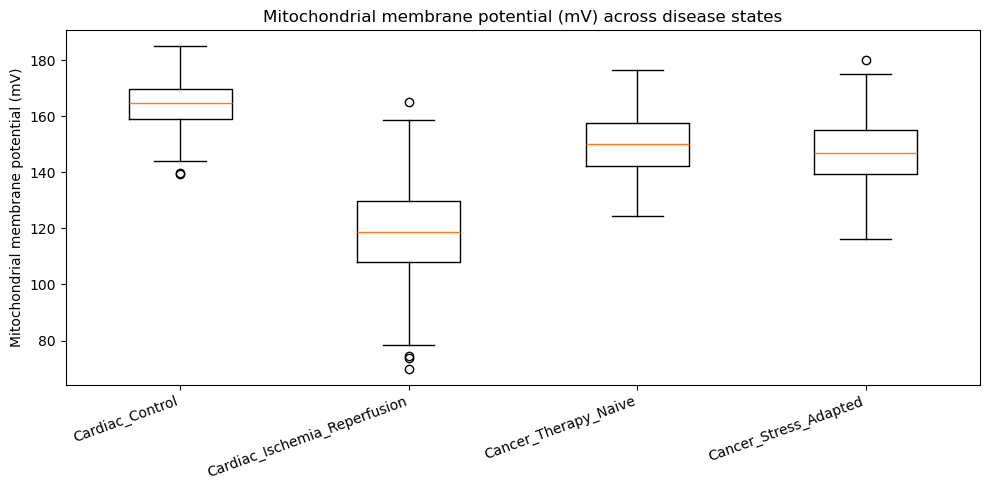

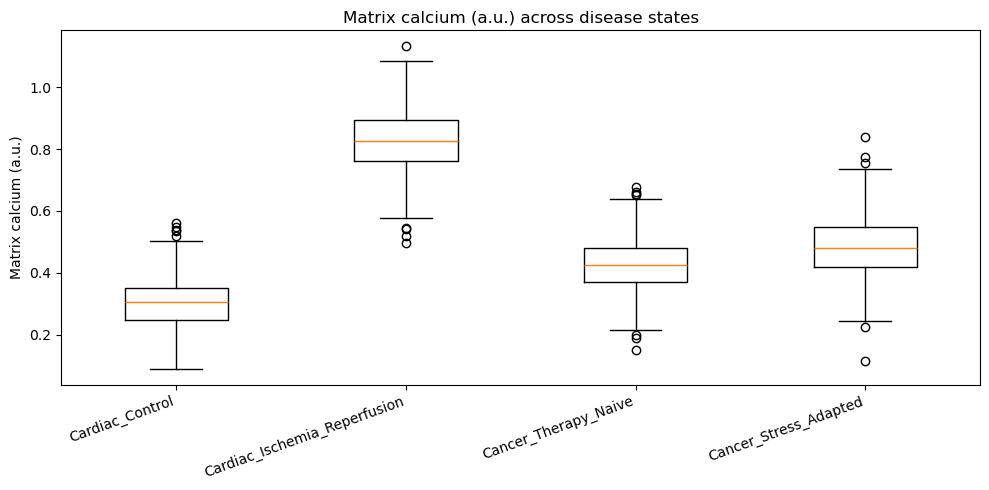

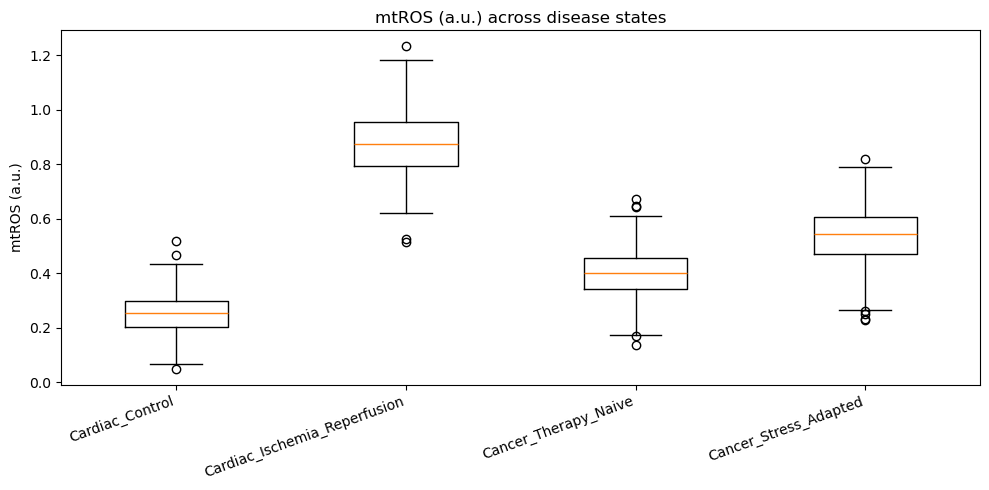

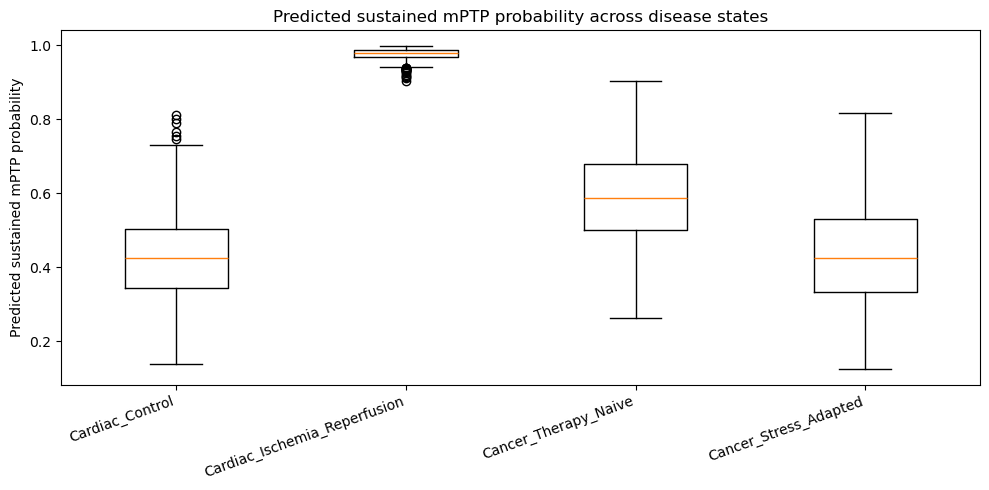

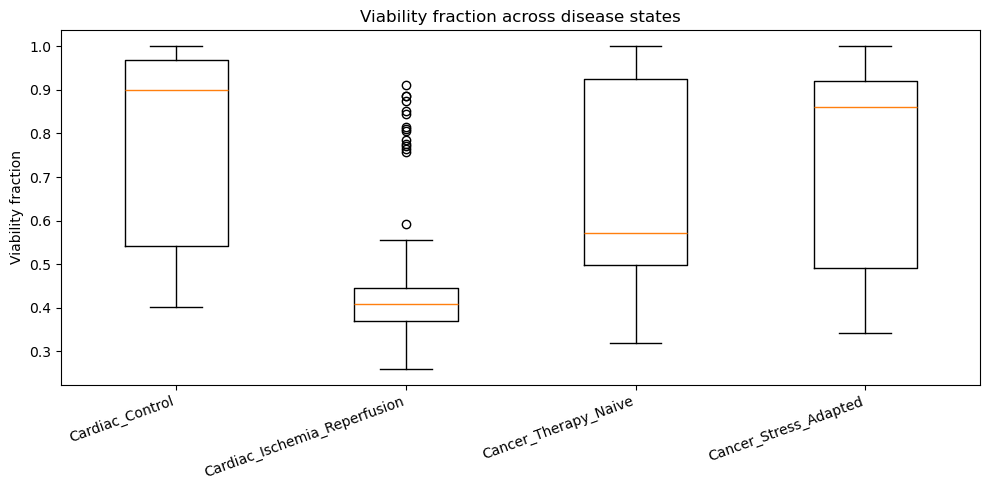

In [38]:

# 3. Visualize major disease-state trends

state_order = ["Cardiac_Control","Cardiac_Ischemia_Reperfusion","Cancer_Therapy_Naive","Cancer_Stress_Adapted"]

def boxplot_metric(metric, ylabel, filename):
    fig, ax = plt.subplots(figsize=(10, 5))
    data = [df.loc[df["state"] == s, metric].values for s in state_order]
    ax.boxplot(data, tick_labels=state_order, patch_artist=False, showfliers=True)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} across disease states")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(fig_dir / filename, dpi=300)
    plt.show()

boxplot_metric("delta_psi_mV", "Mitochondrial membrane potential (mV)", "01_delta_psi_by_state.png")
boxplot_metric("matrix_ca_au", "Matrix calcium (a.u.)", "02_matrix_calcium_by_state.png")
boxplot_metric("mtROS_au", "mtROS (a.u.)", "03_mtros_by_state.png")
boxplot_metric("sustained_pore_prob", "Predicted sustained mPTP probability", "04_sustained_pore_probability_by_state.png")
boxplot_metric("viability_fraction", "Viability fraction", "05_viability_by_state.png")


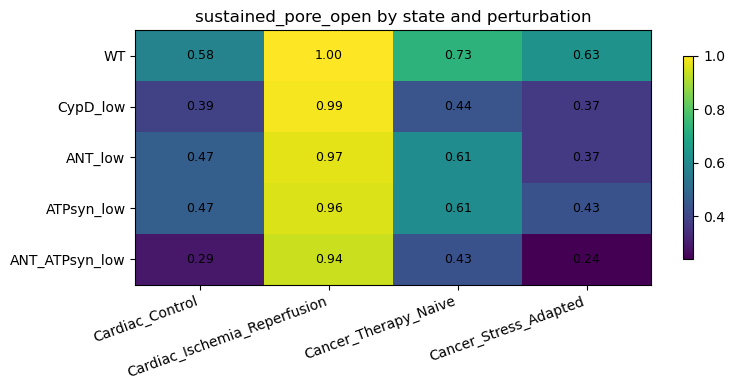

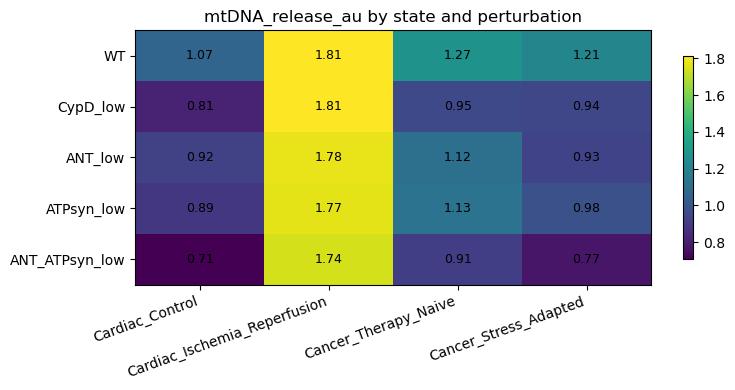

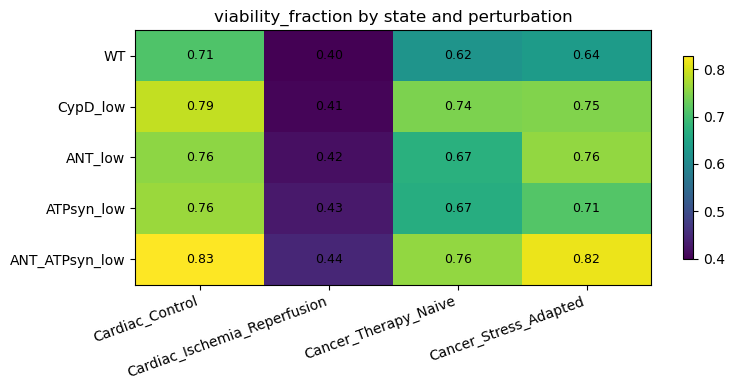

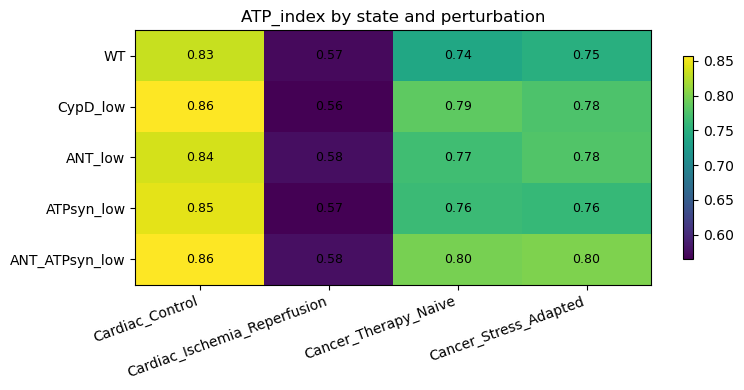

In [10]:

# Heatmap-like summary using plain matplotlib
metrics = ["sustained_pore_open","mtDNA_release_au","viability_fraction","ATP_index"]
heat_df = df.groupby(["state","perturbation"])[metrics].mean().reset_index()

for metric in metrics:
    pivot = heat_df.pivot(index="perturbation", columns="state", values=metric).loc[
        ["WT","CypD_low","ANT_low","ATPsyn_low","ANT_ATPsyn_low"], state_order
    ]
    fig, ax = plt.subplots(figsize=(8,4))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"{metric} by state and perturbation")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    fig.savefig(fig_dir / f"heatmap_{metric}.png", dpi=300)
    plt.show()



The first figures should show the expected literature-aligned trends. **Cardiac ischemia-reperfusion** should display the lowest membrane potential, highest calcium and mtROS, highest sustained pore opening probability, and lowest viability. **Stress-adapted cancer** should retain relatively preserved membrane potential and viability despite elevated mtROS, because the synthetic framework encodes **pore desensitization**. The perturbation heatmaps should show that lowering **CypD**, and in many settings lowering **ANT** or **ATP synthase-associated pore propensity**, protects against sustained opening and improves viability.


In [12]:

# 4. Statistical modelling: what drives sustained pore opening?

feature_cols = [
    "delta_psi_mV","matrix_ca_au","mtROS_au","CypD_activity_au",
    "ANT_function_au","ATPsynthase_pore_propensity_au"
]

X = df[feature_cols]
y = df["sustained_pore_open"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
pred_prob = log_model.predict_proba(X_test)[:,1]
pred_label = (pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, pred_prob)
ap = average_precision_score(y_test, pred_prob)

print("Logistic regression ROC-AUC:", round(auc, 3))
print("Logistic regression Average Precision:", round(ap, 3))
print(classification_report(y_test, pred_label))


Logistic regression ROC-AUC: 0.781
Logistic regression Average Precision: 0.858
              precision    recall  f1-score   support

           0       0.61      0.72      0.66       242
           1       0.79      0.70      0.74       358

    accuracy                           0.70       600
   macro avg       0.70      0.71      0.70       600
weighted avg       0.72      0.70      0.71       600



In [13]:

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=8,
    random_state=42
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:,1]
rf_label = (rf_prob >= 0.5).astype(int)

print("Random forest ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print("Random forest Average Precision:", round(average_precision_score(y_test, rf_prob), 3))

perm = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42)
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp_df.to_csv(table_dir / "random_forest_permutation_importance.csv", index=False)
imp_df


Random forest ROC-AUC: 0.751
Random forest Average Precision: 0.843


,feature,importance_mean,importance_sd
4,ANT_function_au,0.036556,0.011855
1,matrix_ca_au,0.026778,0.010878
3,CypD_activity_au,0.022556,0.018806
5,ATPsynthase_pore_propensity_au,0.021333,0.012250
2,mtROS_au,0.012778,0.007642
0,delta_psi_mV,0.012333,0.007013


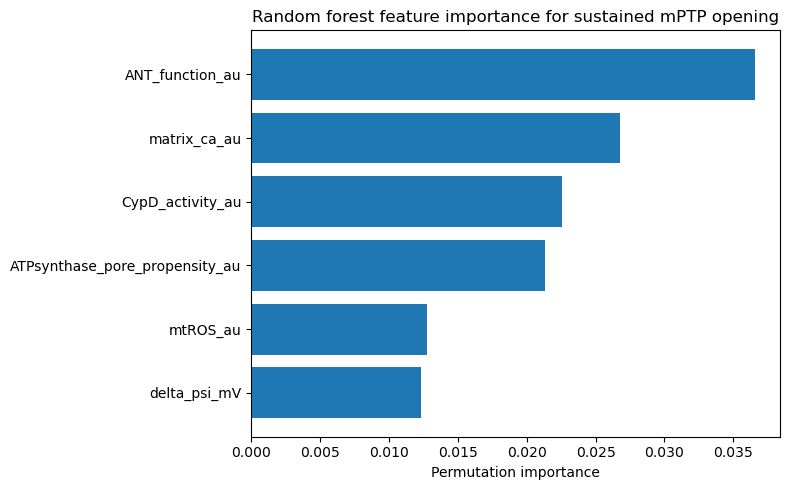

In [14]:

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_df["feature"], imp_df["importance_mean"])
ax.invert_yaxis()
ax.set_xlabel("Permutation importance")
ax.set_title("Random forest feature importance for sustained mPTP opening")
plt.tight_layout()
fig.savefig(fig_dir / "06_feature_importance_sustained_pore.png", dpi=300)
plt.show()



This part of the analysis tests whether the synthetic framework behaves mechanistically as intended. If the simulation is biologically coherent, the strongest predictors of sustained pore opening should be **matrix calcium**, **mtROS**, **CypD activity**, and **Δψm vulnerability**, with ANT and ATP synthase-associated features adding context-dependent explanatory power. That pattern would be consistent with the current conceptual literature on pore gating.


In [16]:

# 5. Regression for viability and mtDNA release

reg_features = feature_cols + ["sustained_pore_open","transient_pore_score"]

Xv = df[reg_features]
yv = df["viability_fraction"]
yr = df["mtDNA_release_au"]

Xv_train, Xv_test, yv_train, yv_test = train_test_split(Xv, yv, test_size=0.30, random_state=42)
_, _, yr_train, yr_test = train_test_split(Xv, yr, test_size=0.30, random_state=42)

rf_reg_v = RandomForestRegressor(n_estimators=400, max_depth=7, random_state=42)
rf_reg_r = RandomForestRegressor(n_estimators=400, max_depth=7, random_state=42)

rf_reg_v.fit(Xv_train, yv_train)
rf_reg_r.fit(Xv_train, yr_train)

yv_pred = rf_reg_v.predict(Xv_test)
yr_pred = rf_reg_r.predict(Xv_test)

print("Viability model R2:", round(r2_score(yv_test, yv_pred), 3))
print("Viability model RMSE:", round(np.sqrt(mean_squared_error(yv_test, yv_pred)), 3))
print("mtDNA release model R2:", round(r2_score(yr_test, yr_pred), 3))
print("mtDNA release model RMSE:", round(np.sqrt(mean_squared_error(yr_test, yr_pred)), 3))


Viability model R2: 0.96
Viability model RMSE: 0.047
mtDNA release model R2: 0.959
mtDNA release model RMSE: 0.126


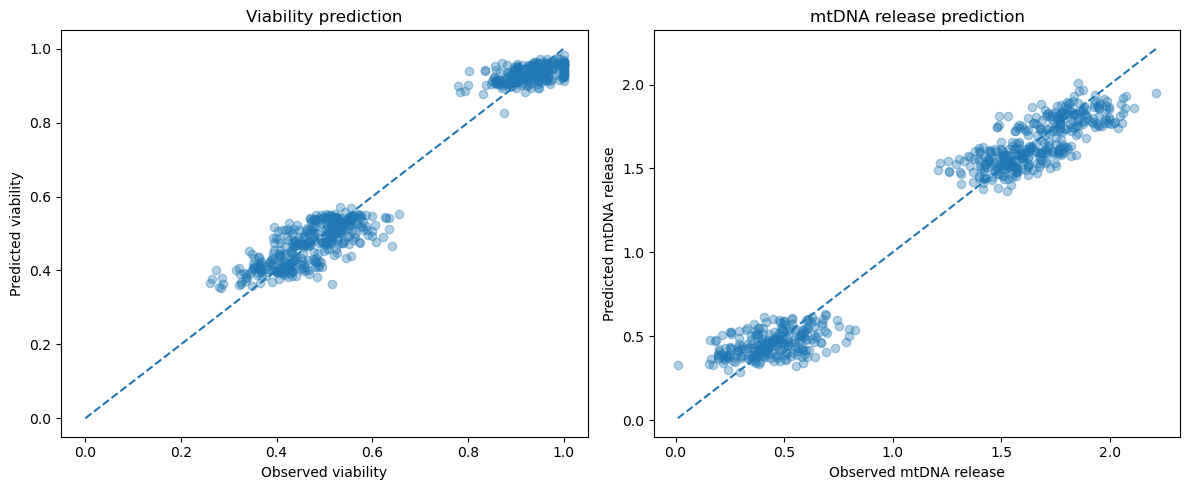

In [17]:

# Predicted vs observed plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(yv_test, yv_pred, alpha=0.35)
axes[0].plot([0,1],[0,1], linestyle="--")
axes[0].set_xlabel("Observed viability")
axes[0].set_ylabel("Predicted viability")
axes[0].set_title("Viability prediction")

axes[1].scatter(yr_test, yr_pred, alpha=0.35)
mn = min(yr_test.min(), yr_pred.min())
mx = max(yr_test.max(), yr_pred.max())
axes[1].plot([mn,mx],[mn,mx], linestyle="--")
axes[1].set_xlabel("Observed mtDNA release")
axes[1].set_ylabel("Predicted mtDNA release")
axes[1].set_title("mtDNA release prediction")

plt.tight_layout()
fig.savefig(fig_dir / "07_regression_prediction_plots.png", dpi=300)
plt.show()



A major reason to build this kind of framework is to support **counterfactual reasoning** before expensive experiments. If the model is useful, it should tell us how much a given perturbation, such as lowering CypD activity, shifts the probability of sustained opening in different disease states. This is not clinical prediction. It is **mechanism-prioritization**.


In [19]:

# 6. Counterfactual intervention simulation

def counterfactual_shift(data, delta_cypd=0.0, delta_ant=0.0, delta_atpsyn=0.0):
    tmp = data.copy()
    tmp["CypD_activity_au"] = np.clip(tmp["CypD_activity_au"] + delta_cypd, 0.01, None)
    tmp["ANT_function_au"] = np.clip(tmp["ANT_function_au"] + delta_ant, 0.01, None)
    tmp["ATPsynthase_pore_propensity_au"] = np.clip(tmp["ATPsynthase_pore_propensity_au"] + delta_atpsyn, 0.01, None)
    probs = rf.predict_proba(tmp[feature_cols])[:,1]
    return probs.mean()

cf_rows = []
for state in state_order:
    subset = df[df["state"] == state]
    base = rf.predict_proba(subset[feature_cols])[:,1].mean()
    cypd_low = counterfactual_shift(subset, delta_cypd=-0.20)
    ant_low = counterfactual_shift(subset, delta_ant=-0.20)
    atp_low = counterfactual_shift(subset, delta_atpsyn=-0.20)
    combo = counterfactual_shift(subset, delta_cypd=-0.20, delta_ant=-0.20, delta_atpsyn=-0.20)
    cf_rows.append({
        "state": state,
        "baseline_predicted_sustained_pore_prob": base,
        "CypD_reduction": cypd_low,
        "ANT_reduction": ant_low,
        "ATPsynthase_reduction": atp_low,
        "Combined_reduction": combo
    })

cf_df = pd.DataFrame(cf_rows)
cf_df.to_csv(table_dir / "counterfactual_intervention_summary.csv", index=False)
cf_df


,state,baseline_predicted_sustained_pore_prob,CypD_reduction,ANT_reduction,ATPsynthase_reduction,Combined_reduction
0,Cardiac_Control,0.442846,0.357389,0.404169,0.417009,0.313043
1,Cardiac_Ischemia_Reperfusion,0.958540,0.935264,0.945858,0.934464,0.884903
2,Cancer_Therapy_Naive,0.504066,0.421614,0.448949,0.466284,0.339536
3,Cancer_Stress_Adapted,0.463159,0.411613,0.409152,0.435056,0.331328


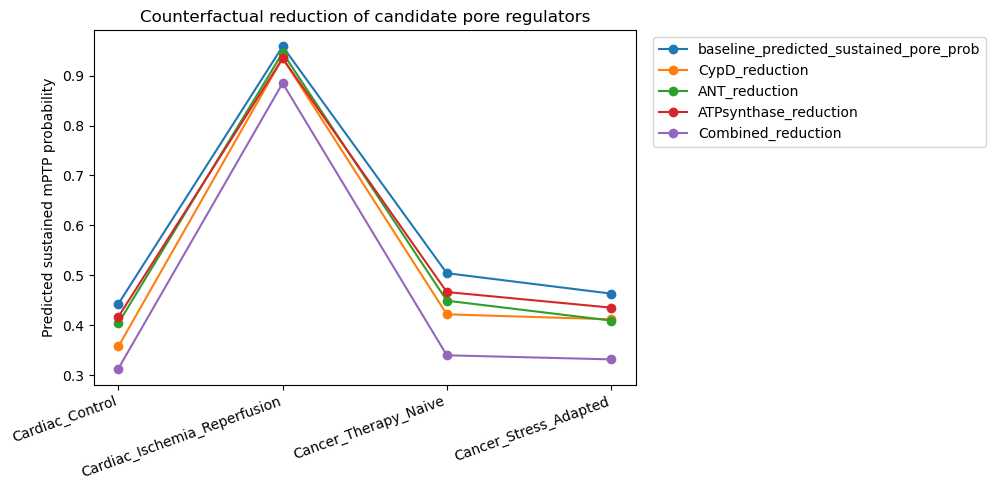

In [20]:

plot_df = cf_df.set_index("state")
fig, ax = plt.subplots(figsize=(10,5))
for col in plot_df.columns:
    ax.plot(plot_df.index, plot_df[col], marker="o", label=col)
ax.set_ylabel("Predicted sustained mPTP probability")
ax.set_title("Counterfactual reduction of candidate pore regulators")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
fig.savefig(fig_dir / "08_counterfactual_interventions.png", dpi=300)
plt.show()



## Interpretation

This proof-of-concept notebook demonstrates a practical computational strategy for the proposed mPTP programme.

The synthetic data support three biologically meaningful ideas.

First, **cardiac ischemia-reperfusion** behaves as a pore-sensitive disease state in which elevated calcium, mtROS, and CypD sensitization push mitochondria toward sustained opening, mtDNA release, ATP loss, and reduced viability.

Second, **stress-adapted cancer** can be represented as a state in which oxidative and metabolic stress persist, but the threshold for sustained catastrophic opening is shifted upward.

Third, a multivariable, interpretable framework can be used to rank candidate mechanistic interventions, such as lowering **CypD**, **ANT**, or **ATP synthase-associated pore propensity**, before moving into wet-lab experiments.

This notebook is a **proof of concept**, not an empirical claim about any one disease cohort. Its value is to show how literature-grounded synthetic data can be used to formalize hypotheses, stress-test a study design, and generate analysis templates for future experimental data.


In [22]:

# ------------------------------------------------------------
# 7. Save full synthetic dataset
# ------------------------------------------------------------
df.to_csv(table_dir / "synthetic_mptp_single_cell_dataset.csv", index=False)

print("Saved dataset and outputs to:")
print(output_dir.resolve())
print("\nFigure files:")
for p in sorted(fig_dir.glob("*.png")):
    print(" -", p.name)
print("\nTable files:")
for p in sorted(table_dir.glob("*.csv")):
    print(" -", p.name)


Saved dataset and outputs to:
/Users/petalc01/mPTP Research Proposal/mptp_outputs

Figure files:
 - 01_delta_psi_by_state.png
 - 02_matrix_calcium_by_state.png
 - 03_mtros_by_state.png
 - 04_sustained_pore_probability_by_state.png
 - 05_viability_by_state.png
 - 06_feature_importance_sustained_pore.png
 - 07_regression_prediction_plots.png
 - 08_counterfactual_interventions.png
 - heatmap_ATP_index.png
 - heatmap_mtDNA_release_au.png
 - heatmap_sustained_pore_open.png
 - heatmap_viability_fraction.png

Table files:
 - counterfactual_intervention_summary.csv
 - random_forest_permutation_importance.csv
 - state_perturbation_summary.csv
 - state_summary_statistics.csv
 - synthetic_mptp_single_cell_dataset.csv
